In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
from torch_geometric.data import Data
print(os.getpid())

1311275


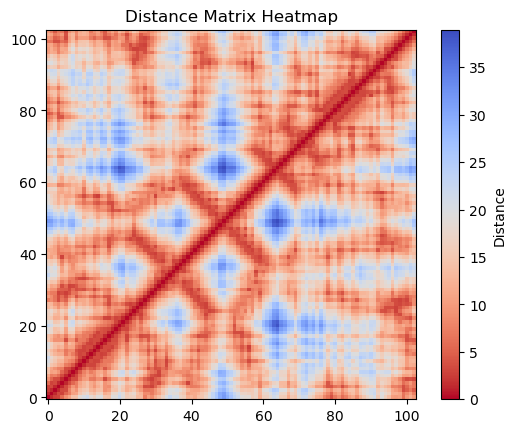

In [2]:
import sequenceHandler  
import importlib
importlib.reload(sequenceHandler)

from sequenceHandler import distance_map_PDB
pdb_file = "PDB/PF00017.pdb"
chain_id = "A"
output_map_file = "None"  

distance_map, residue = distance_map_PDB(pdb_file, chain_id, output_map_file)

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(distance_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Matrix Heatmap")
plt.show()

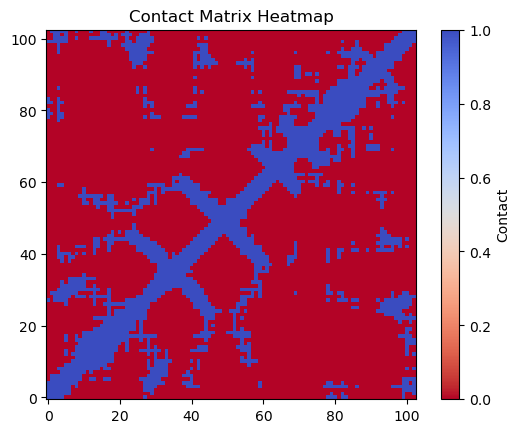

In [3]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  

contact_map = contact_from_distance(distance_map, threshold=8.0)

plt.figure()
plt.imshow(contact_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Contact")
plt.title("Contact Matrix Heatmap")
plt.show()

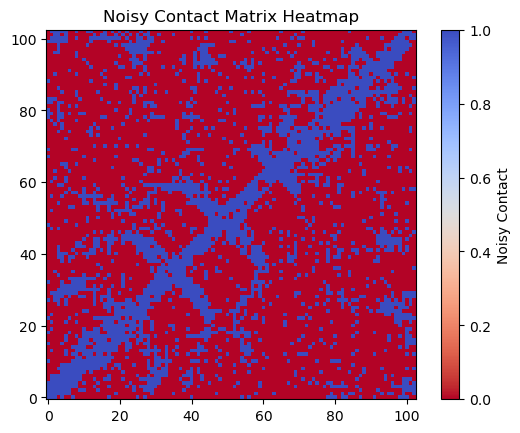

In [4]:
def create_noisy_contact_map(contact_map, noise_level=0.1):
    noisy_contact_map = contact_map.copy()
    num_elements = contact_map.size
    num_noisy_elements = int(noise_level * num_elements)
    
    indices = np.random.choice(num_elements, num_noisy_elements, replace=False)
    noisy_contact_map.flat[indices] = 1 - noisy_contact_map.flat[indices]
    
    return noisy_contact_map

noisy_contact_map= create_noisy_contact_map(contact_map, noise_level=0.1)

plt.figure()
plt.imshow(noisy_contact_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Noisy Contact")
plt.title("Noisy Contact Matrix Heatmap")
plt.show()  

In [5]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [ ]:
def build_graph_contact_topk(noisy_contact_map, true_contact_map=None, sep_min=5, k=64):
    noisy_contact_map = torch.as_tensor(noisy_contact_map, dtype=torch.float32)
    N = noisy_contact_map.size(0)

    edges_i = []
    edges_j = []
    edge_attr_list = []
    labels_list = []
    pair_mask_list = []
    edge_mask_list = []

    if true_contact_map is not None:
        true_contact_map = torch.as_tensor(true_contact_map, dtype=torch.float32)

    for i in range(N):
        # valid candidates
        candidates = torch.arange(N)
        mask = (candidates != i) & (torch.abs(candidates - i) >= sep_min)
        candidates = candidates[mask]

        scores = noisy_contact_map[i, candidates]

        # top-k selection
        if candidates.numel() > k:
            topk_idx = torch.topk(scores, k=k).indices
            candidates = candidates[topk_idx]
            scores = scores[topk_idx]

        edges_i.append(torch.full_like(candidates, i))
        edges_j.append(candidates)
        edge_attr_list.append(scores)
    
        # pair mask: keep only upper triangle
        pair_mask = i < candidates

        # long-range condition (already enforced, but keep for consistency)
        long_range_ok = torch.abs(candidates - i) >= sep_min

        if true_contact_map is not None:
            labels = (true_contact_map[i, candidates] == 1).float()
        else:
            labels = torch.zeros_like(scores)

        labels_list.append(labels)

        pair_mask_list.append(pair_mask)
        edge_mask_list.append(long_range_ok)

    i = torch.cat(edges_i)
    j = torch.cat(edges_j)

    edge_index = torch.stack([i, j], dim=0)
    edge_attr = torch.cat(edge_attr_list).unsqueeze(-1)
    y = torch.cat(labels_list).unsqueeze(-1)

      
    edge_mask = torch.cat(edge_mask_list)
    pair_mask = torch.cat(pair_mask_list)

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        edge_mask=edge_mask,
        pair_mask=pair_mask,
        L=N
    )

In [56]:
import sequenceHandler  
import importlib
importlib.reload(sequenceHandler)
from sequenceHandler import distance_map_PDB

folder_path = "PDB"

all_data = []
for file in os.listdir(folder_path):
    pdb_path = os.path.join(folder_path, file)
    chain_id = "A"
    output_map_file = "None"  

    try:
        distance_map, __ = distance_map_PDB(pdb_path, chain_id, output_map_file)
        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        noisy_contact_map= create_noisy_contact_map(true_contact_map, noise_level=0.1)
        data = build_graph_contact_topk(noisy_contact_map, true_contact_map)
        all_data.append(data)
    except:
        print(f"Some error occurred in the sequence {file}")

torch.save(all_data, "all_data.pt") 


Some error occurred in the sequence PF07714.pdb
Some error occurred in the sequence PF00016.pdb
Some error occurred in the sequence PF00031.pdb
Some error occurred in the sequence PF00044.pdb
Some error occurred in the sequence PF00046.pdb
Some error occurred in the sequence PF00050.pdb
Some error occurred in the sequence PF00058.pdb
Some error occurred in the sequence PF00069.pdb
Some error occurred in the sequence PF00073.pdb
Some error occurred in the sequence PF00082.pdb
Some error occurred in the sequence PF00095.pdb
Some error occurred in the sequence PF00096.pdb
Some error occurred in the sequence PF00098.pdb
Some error occurred in the sequence PF00101.pdb
Some error occurred in the sequence PF00111.pdb
Some error occurred in the sequence PF00121.pdb
Some error occurred in the sequence PF00124.pdb
Some error occurred in the sequence PF00130.pdb
Some error occurred in the sequence PF00157.pdb
Some error occurred in the sequence PF00170.pdb
Some error occurred in the sequence PF00

In [57]:
all_data = torch.load("all_data.pt",weights_only=False)
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=1)


train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
#train_loader = DataLoader([all_data[3]], batch_size=1)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [58]:
print(test_loader.dataset[0])

Data(x=[342, 16], edge_index=[2, 21888], edge_attr=[21888, 1], y=[21888, 1], edge_mask=[21888], pair_mask=[21888], L=342)


In [59]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out

In [60]:
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, edge_in_ch = 8, hidden_ch=128, mlp_hidden_ch=64,GNN_layers=4,node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:
            self.edge_norms.append(LayerNorm(edge_in_ch))
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = edge_in_ch,
            node_out_ch = hidden_ch,
            edge_out_ch = hidden_ch
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 1):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(hidden_ch))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(hidden_ch))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=hidden_ch,
                edge_in_ch=hidden_ch,
                node_out_ch=hidden_ch,
                edge_out_ch=hidden_ch
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(hidden_ch, hidden_ch),
                nn.Sigmoid()
                ))


         # MLP head for edge classification
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.ReLU(),
            nn.Linear(mlp_hidden_ch, 1)   # one logit
        )


    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        #edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente
        batch = getattr(graph, "batch", None)
        for i, conv in enumerate(self.convs):
            x_in = x
            e_in = edge_attr

            x = self.node_norms[i](x, batch) if self.node_norms is not None else x
            edge_attr = self.edge_norms[i](edge_attr) if self.edge_norms is not None else edge_attr

            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in

            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)

        # Final projection to output space
        edge_attr = self.edge_head(edge_attr)

        return x, edge_attr

In [61]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [62]:
def average_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_edges = 0
    total_batches= 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, pred_logits = model(batch)
            pred_logits = pred_logits.squeeze(-1)
            true_contacts = batch.y.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss = loss_fn(pred_logits[mask], true_contacts[mask])

            n_edges = mask.sum().item()
            total_loss += loss.item() * n_edges
            total_edges += n_edges
            total_batches += 1

    return total_loss / max(total_edges, 1)


In [63]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EdgeGNN(node_in_ch=16, edge_in_ch=1, hidden_ch=25, mlp_hidden_ch=12, GNN_layers=3).to(device)

pos_weight = compute_pos_weight(train_loader, device)
print("pos_weight:", pos_weight.item())
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction='mean')

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_losses = []

for epoch in range(200):

    model.train()

    total_loss = 0.0
    total_edges = 0
    for batch in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()

        _, pred_logits = model(batch)

        pred_logits = pred_logits.squeeze(-1)
        true_contacts = batch.y.squeeze(-1)

        mask = batch.edge_mask #& batch.pair_mask

        loss = loss_fn(pred_logits[mask], true_contacts[mask])

        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        optimizer.step()

    train_loss = total_loss / max(total_edges, 1)
    val_loss = average_loss(model, test_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

pos_weight: 3.4775872230529785
Epoch 0: Train Loss=0.8230, Val Loss=0.7516
Epoch 1: Train Loss=0.7115, Val Loss=0.7398
Epoch 2: Train Loss=0.6853, Val Loss=0.6913
Epoch 3: Train Loss=0.6545, Val Loss=0.6530
Epoch 4: Train Loss=0.6328, Val Loss=0.6398
Epoch 5: Train Loss=0.6177, Val Loss=0.6418
Epoch 6: Train Loss=0.6132, Val Loss=0.6249
Epoch 7: Train Loss=0.6050, Val Loss=0.6215
Epoch 8: Train Loss=0.5982, Val Loss=0.6143
Epoch 9: Train Loss=0.5928, Val Loss=0.6145
Epoch 10: Train Loss=0.5879, Val Loss=0.6086
Epoch 11: Train Loss=0.5855, Val Loss=0.6063
Epoch 12: Train Loss=0.5839, Val Loss=0.5911
Epoch 13: Train Loss=0.5773, Val Loss=0.5950
Epoch 14: Train Loss=0.5694, Val Loss=0.5846
Epoch 15: Train Loss=0.5704, Val Loss=0.5885
Epoch 16: Train Loss=0.5652, Val Loss=0.5825
Epoch 17: Train Loss=0.5679, Val Loss=0.5773
Epoch 18: Train Loss=0.5610, Val Loss=0.5747
Epoch 19: Train Loss=0.5585, Val Loss=0.5830
Epoch 20: Train Loss=0.5544, Val Loss=0.5777
Epoch 21: Train Loss=0.5546, Val L

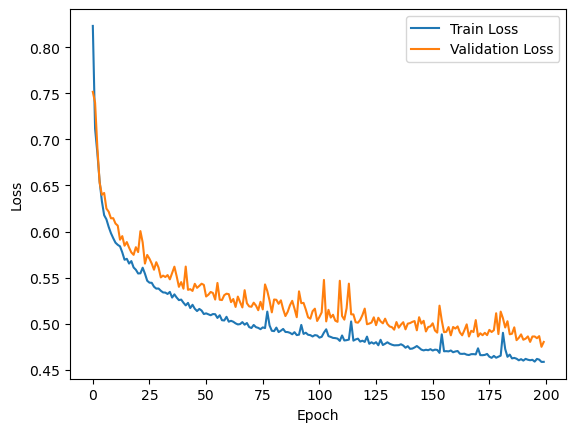

In [64]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Precision of the GNN: 0.8692278629314588
Recall of the GNN: 0.4958957230883621
F1 of the GNN: 0.63151261033254
AUPRC of the GNN: 0.8252747838725708
Validation ROC AUC GNN: 0.9410088817920091


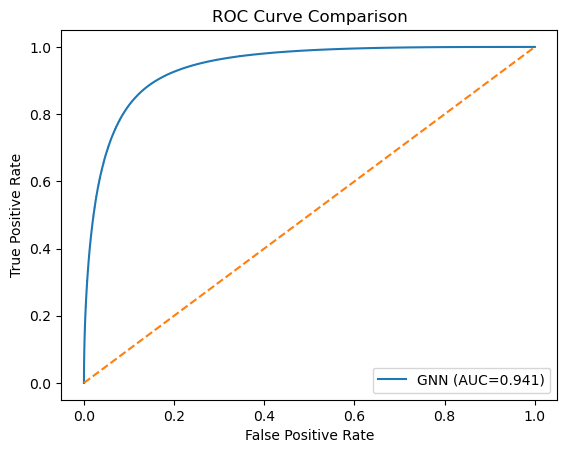

PR AUC GNN: 0.8252753636527673


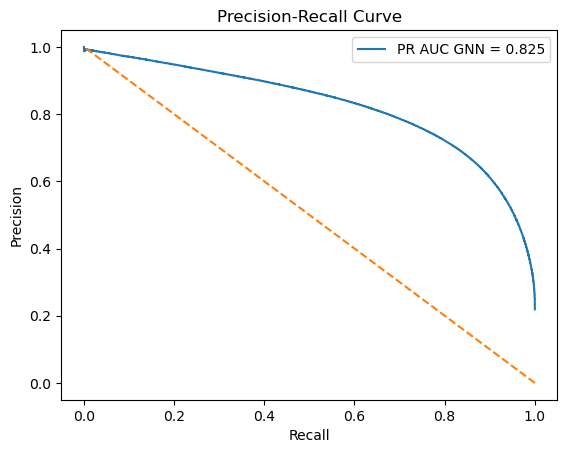

In [65]:
from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve

model.eval()

all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)


threshold=0.9

pred_contacts = (all_probs >= threshold).int().numpy()
true_contacts = all_true.int().numpy()

precision = precision_score(true_contacts, pred_contacts, zero_division=0)
recall = recall_score(true_contacts, pred_contacts, zero_division=0)
f1 = f1_score(true_contacts, pred_contacts, zero_division=0)
auprc = average_precision_score(true_contacts, all_probs.numpy())

print(f"Precision of the GNN: {np.mean(precision)}")
print(f"Recall of the GNN: {np.mean(recall)}")
print(f"F1 of the GNN: {np.mean(f1)}")
print(f"AUPRC of the GNN: {np.mean(auprc)}")



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [66]:

def topk_L_precision(model, loader, device, ratio=1.0):
    model.eval()
    per_graph_precisions = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, logits = model(batch)

            probs = torch.sigmoid(logits.squeeze(-1))
            true_contacts = batch.y.squeeze(-1)

            valid_mask = batch.edge_mask & batch.pair_mask

            # graph id for each edge
            edge_graph_id = batch.batch[batch.edge_index[0]]

            num_graphs = batch.num_graphs

            for g in range(num_graphs):
                graph_mask = valid_mask & (edge_graph_id == g)

                probs_g = probs[graph_mask]
                true_g = true_contacts[graph_mask]

                if probs_g.numel() == 0:
                    continue

                # length of the protein
                L = int(batch.L[g]) if torch.is_tensor(batch.L) else int(batch.L)

                k = max(1, int(L * ratio))
                k = min(k, probs_g.numel())

                top_idx = torch.topk(probs_g, k=k).indices
                #knumber of true contacts in top-k​/k
                precision_g = (true_g[top_idx] > 0.5).float().mean().item()

                per_graph_precisions.append(precision_g)

    return float(np.mean(per_graph_precisions)), per_graph_precisions

print("Top-k*L precision:", topk_L_precision(model, test_loader, device, ratio=1)[0])

Top-k*L precision: 0.9704315742497803


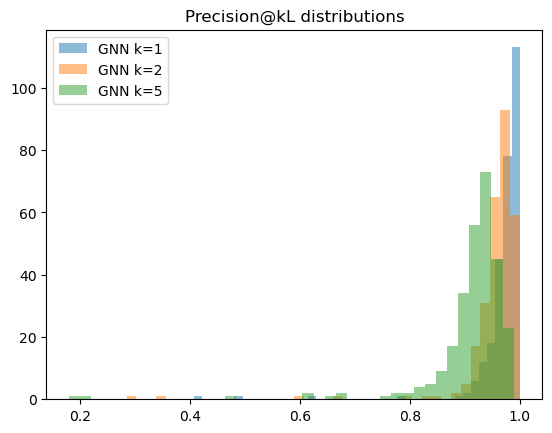

In [67]:
k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, alpha=0.5, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [68]:
k=1
precision= topk_L_precision(model, test_loader, device, ratio=k)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))

[0.988304078578949, 0.9530791640281677, 0.9999999403953552, 1.0, 0.9685534238815308, 0.950276255607605, 0.9815497994422913, 0.9589040875434875, 0.98333340883255, 0.966292142868042, 0.9922178983688354, 0.9788135886192322, 0.9932432770729065, 0.9845678806304932, 0.9924242496490479, 0.993630588054657, 0.9881423115730286, 0.9809885621070862, 0.9870129823684692, 0.9825581312179565, 0.9340659379959106, 0.9386188983917236, 0.9948051571846008, 0.9965753555297852, 1.0, 0.9753086566925049, 0.9874213337898254, 1.0, 0.9830508232116699, 1.0, 0.9904762506484985, 0.9760765433311462, 0.9755101799964905, 0.8985507488250732, 0.9729729890823364, 0.9685534238815308, 0.9797979593276978, 0.9785714149475098, 0.9765258431434631, 0.9895104765892029, 0.9852941036224365, 0.9690476655960083, 0.9952381253242493, 0.6238532066345215, 0.9507042169570923, 0.9741935133934021, 0.9746376872062683, 0.9953270554542542, 0.9726027250289917, 0.9672130346298218, 1.0, 0.996874988079071, 0.9337016940116882, 0.9928057789802551, 0

In [69]:
def graph_to_matrix(data, values):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

Data(x=[780, 16], edge_index=[2, 49920], edge_attr=[49920, 1], y=[49920, 1], edge_mask=[49920], pair_mask=[49920], L=780)


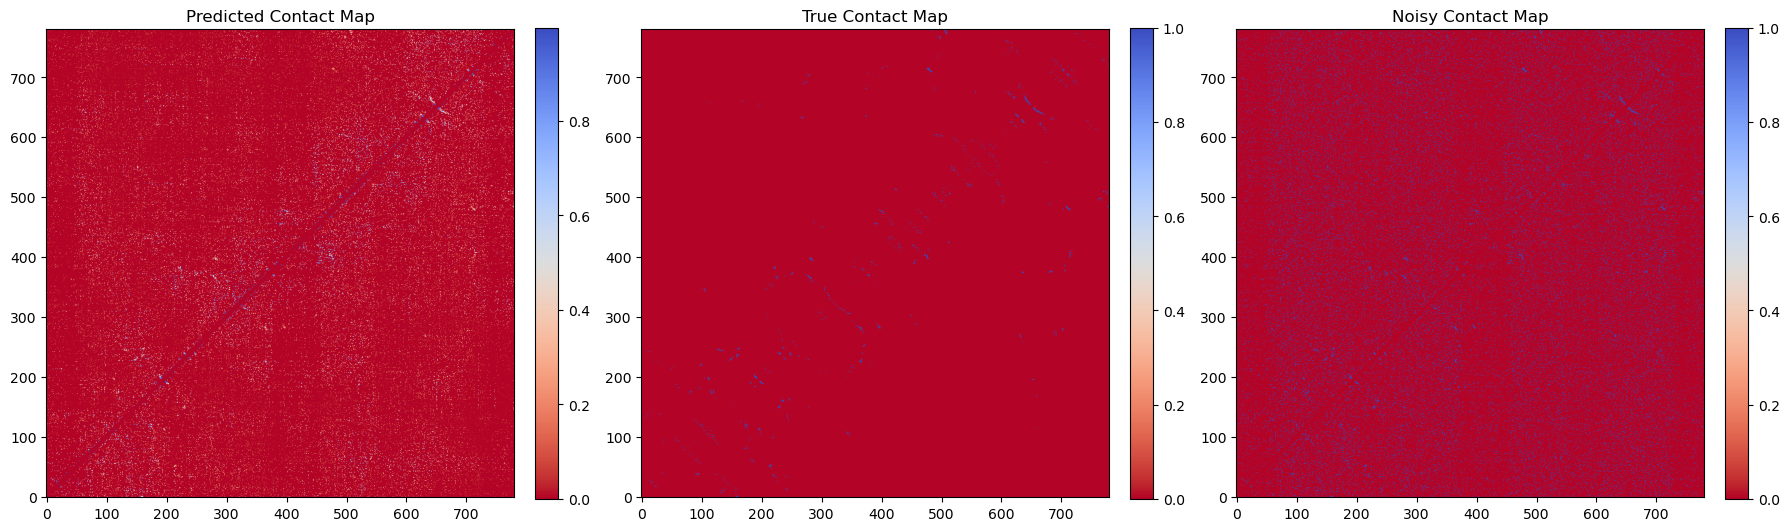

In [71]:
pos=145
#worst case

i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)

mask = batch.edge_mask & batch.pair_mask

scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.8
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map_map, cmap='coolwarm_r', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()